# Session 5 — Evaluation, Tuning & Explainability

This notebook continues from Session 4.

**Order:** setup → reload Session 3 split data → reload five fitted Session 4 pipelines → ROC curves for all 5 → top 2 confusion matrices → select Session 4 CV-AUC winner → RandomizedSearchCV → evaluate tuned model once on untouched test set → final ROC → classification report → SHAP → save/reload `.pkl` → model card → model-choice justification → validation checklist.

The held-out test set is not used for hyperparameter selection.

In [ ]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import shap

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../models/final", exist_ok=True)
os.makedirs("../docs", exist_ok=True)

In [ ]:
X_train = pd.read_csv("../data/clean_X_train.csv")
X_test = pd.read_csv("../data/clean_X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/y_test.csv").squeeze("columns")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 22)
X_test : (1409, 22)
y_train: (5634,)
y_test : (1409,)


In [ ]:
model_files = {
    "Logistic Regression": "../models/session4/logistic_regression.pkl",
    "Random Forest": "../models/session4/random_forest.pkl",
    "Gradient Boosting": "../models/session4/gradient_boosting.pkl",
    "Extra Trees": "../models/session4/extra_trees.pkl",
    "KNN": "../models/session4/knn.pkl"
}

pipelines = {}
for name, path in model_files.items():
    pipelines[name] = joblib.load(path)
    print(f"{name}: loaded")

Logistic Regression: loaded
Random Forest: loaded
Gradient Boosting: loaded
Extra Trees: loaded
KNN: loaded


In [ ]:
cv_df = pd.read_csv("../outputs/cross_validation_auc.csv")
cv_df = cv_df.sort_values("CV AUC Mean", ascending=False).reset_index(drop=True)
cv_df

,Model,CV AUC Mean,CV AUC Std,CV AUC Min,CV AUC Max
0,Logistic Regression,0.847214,0.011065,0.829607,0.859087
1,Gradient Boosting,0.846973,0.011410,0.830886,0.861073
2,Random Forest,0.825940,0.011762,0.810067,0.844850
3,Extra Trees,0.797563,0.015205,0.784754,0.823592
4,KNN,0.783853,0.008326,0.776921,0.799068


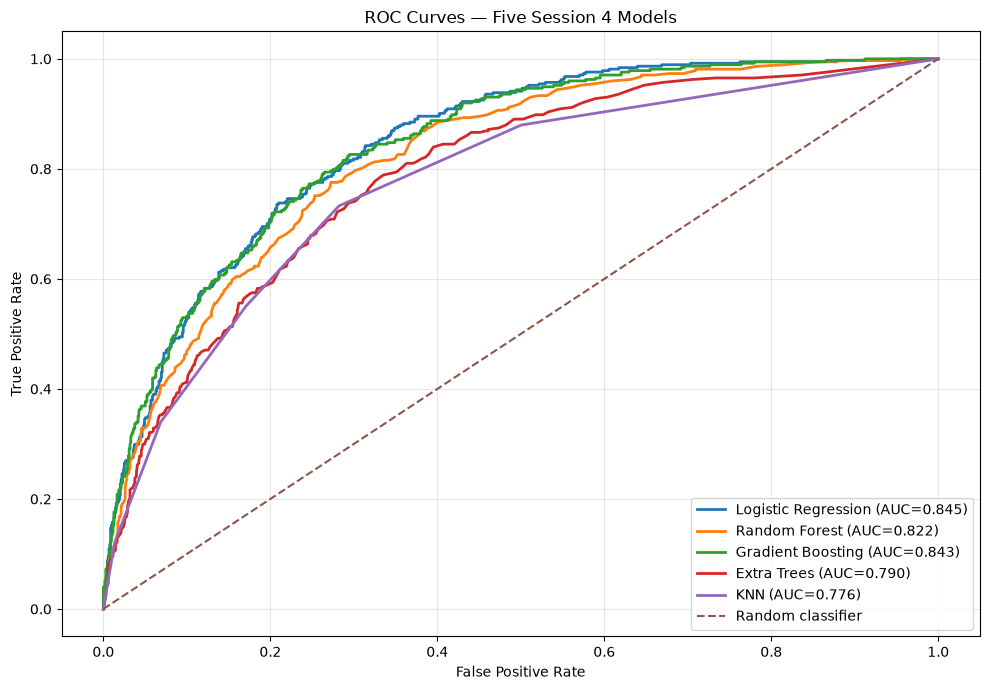

,Model,Test AUC
0,Logistic Regression,0.844966
1,Gradient Boosting,0.842694
2,Random Forest,0.822435
3,Extra Trees,0.790337
4,KNN,0.775867


In [ ]:
plt.figure(figsize=(10, 7))

roc_rows = []
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_rows.append({"Model": name, "Test AUC": auc_score})
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Five Session 4 Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

roc_df = pd.DataFrame(roc_rows).sort_values("Test AUC", ascending=False).reset_index(drop=True)
roc_df

In [ ]:
top_2_models = cv_df.head(2)["Model"].tolist()

print("Top 2 models by Session 4 mean CV AUC:")
for i, name in enumerate(top_2_models, 1):
    score = cv_df.loc[cv_df["Model"] == name, "CV AUC Mean"].iloc[0]
    print(f"{i}. {name}: {score:.4f}")

Top 2 models by Session 4 mean CV AUC:
1. Logistic Regression: 0.8472
2. Gradient Boosting: 0.8470


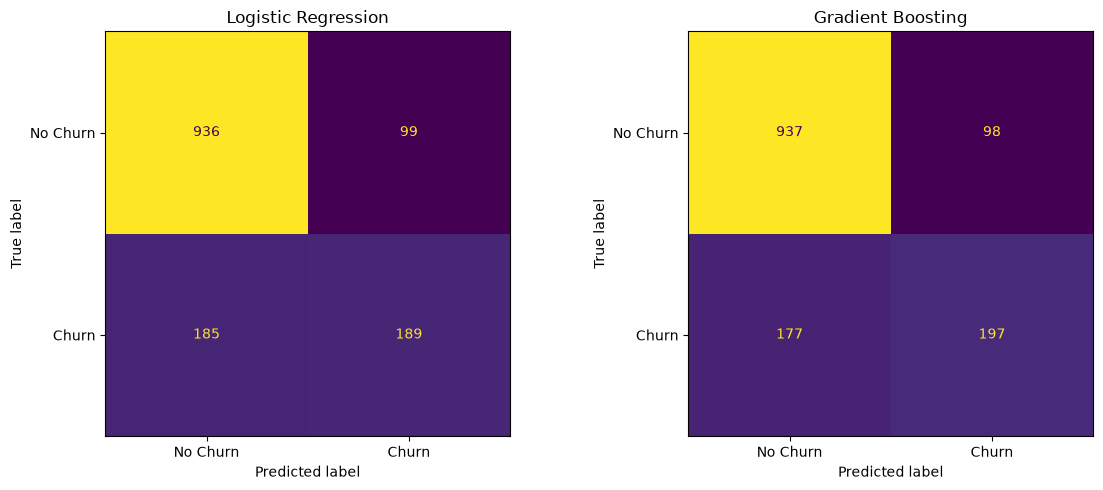

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, top_2_models):
    y_pred = pipelines[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    ).plot(ax=ax, values_format="d", colorbar=False)

    ax.set_title(name)

plt.tight_layout()
plt.savefig("../outputs/confusion_matrix_top2.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
best_model_name = cv_df.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]

print("Model selected for tuning:", best_model_name)
print(f"Session 4 mean CV AUC: {cv_df.iloc[0]['CV AUC Mean']:.4f}")
print(best_pipeline)

Model selected for tuning: Logistic Regression
Session 4 mean CV AUC: 0.8472
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'NumServices',
                                                   'AvgMonthlyCharge']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',


In [ ]:
param_distributions = {
    "Logistic Regression": {
        "model__C": np.logspace(-3, 2, 20),
        "model__solver": ["liblinear", "lbfgs"],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": [None, "balanced"]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Extra Trees": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": [None, "balanced"]
    },
    "KNN": {
        "model__n_neighbors": list(range(3, 21)),
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    }
}

In [ ]:
search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distributions[best_model_name],
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1
)

search.fit(X_train, y_train)

final_model = search.best_estimator_

print("Tuned CV AUC:", search.best_score_)
print("\nBest parameters:")
for key, value in search.best_params_.items():
    print(f"{key}: {value}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tuned CV AUC: 0.848104155881144

Best parameters:
model__solver: lbfgs
model__class_weight: None
model__C: 0.12742749857031335


In [ ]:
# FINAL TEST EVALUATION — ONCE
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

final_auc = roc_auc_score(y_test, y_test_prob)
final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred, zero_division=0)
final_recall = recall_score(y_test, y_test_pred, zero_division=0)
final_f1 = f1_score(y_test, y_test_pred, zero_division=0)

final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    "Score": [final_accuracy, final_precision, final_recall, final_f1, final_auc]
})

final_metrics

,Metric,Score
0,Accuracy,0.800568
1,Precision,0.659794
2,Recall,0.513369
3,F1,0.577444
4,ROC_AUC,0.845300


In [ ]:
final_metrics.to_csv("../outputs/final_test_metrics.csv", index=False)

final_report = classification_report(
    y_test, y_test_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
)

print(final_report)

with open("../outputs/final_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(final_report)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



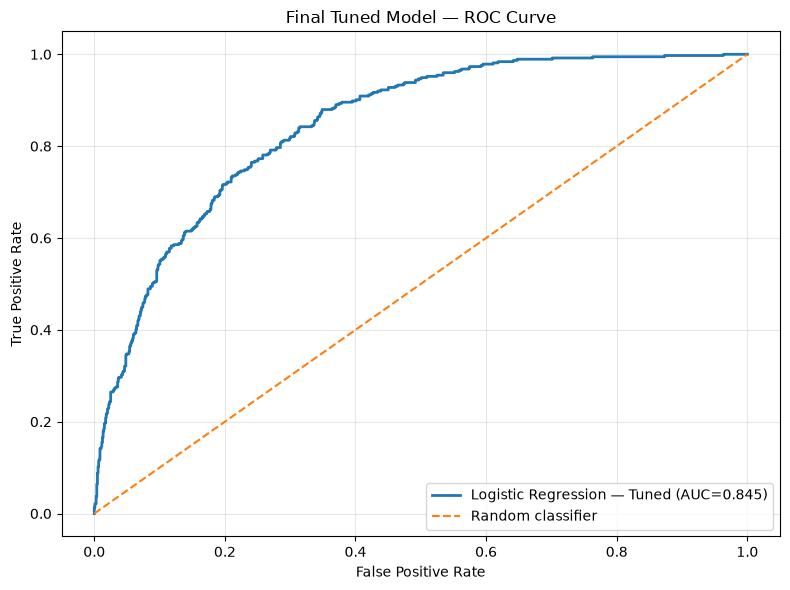

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"{best_model_name} — Tuned (AUC={final_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Tuned Model — ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/final_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# SHAP preparation
preprocessor = final_model.named_steps["preprocessor"]
model = final_model.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

if hasattr(X_train_transformed, "toarray"):
    X_train_shap = X_train_transformed.toarray()
else:
    X_train_shap = np.asarray(X_train_transformed)

if hasattr(X_test_transformed, "toarray"):
    X_test_shap = X_test_transformed.toarray()
else:
    X_test_shap = np.asarray(X_test_transformed)

try:
    feature_names = list(preprocessor.get_feature_names_out())
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_train_shap.shape[1])]

print("Transformed train:", X_train_shap.shape)
print("Transformed test :", X_test_shap.shape)
print("Features:", len(feature_names))

Transformed train: (5634, 52)
Transformed test : (1409, 52)
Features: 52


In [ ]:
# SHAP explanation
model_type = type(model).__name__

if model_type in {"RandomForestClassifier", "ExtraTreesClassifier", "GradientBoostingClassifier"}:
    explainer = shap.TreeExplainer(model)
    shap_output = explainer.shap_values(X_test_shap)

elif model_type == "LogisticRegression":
    explainer = shap.LinearExplainer(model, X_train_shap)
    shap_output = explainer.shap_values(X_test_shap)

else:
    # KNN: model-agnostic explanation on a bounded sample for practicality.
    background = shap.sample(
        X_train_shap,
        min(100, len(X_train_shap)),
        random_state=RANDOM_STATE
    )
    explain_X = X_test_shap[:min(500, len(X_test_shap))]
    explainer = shap.Explainer(
        lambda data: model.predict_proba(data)[:, 1],
        background
    )
    shap_output = explainer(explain_X)

if isinstance(shap_output, list):
    shap_values_plot = shap_output[1]
elif hasattr(shap_output, "values"):
    shap_values_plot = shap_output.values
else:
    shap_values_plot = shap_output

if getattr(shap_values_plot, "ndim", 0) == 3:
    shap_values_plot = shap_values_plot[:, :, 1]

print("SHAP values shape:", np.asarray(shap_values_plot).shape)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


SHAP values shape: (1409, 52)


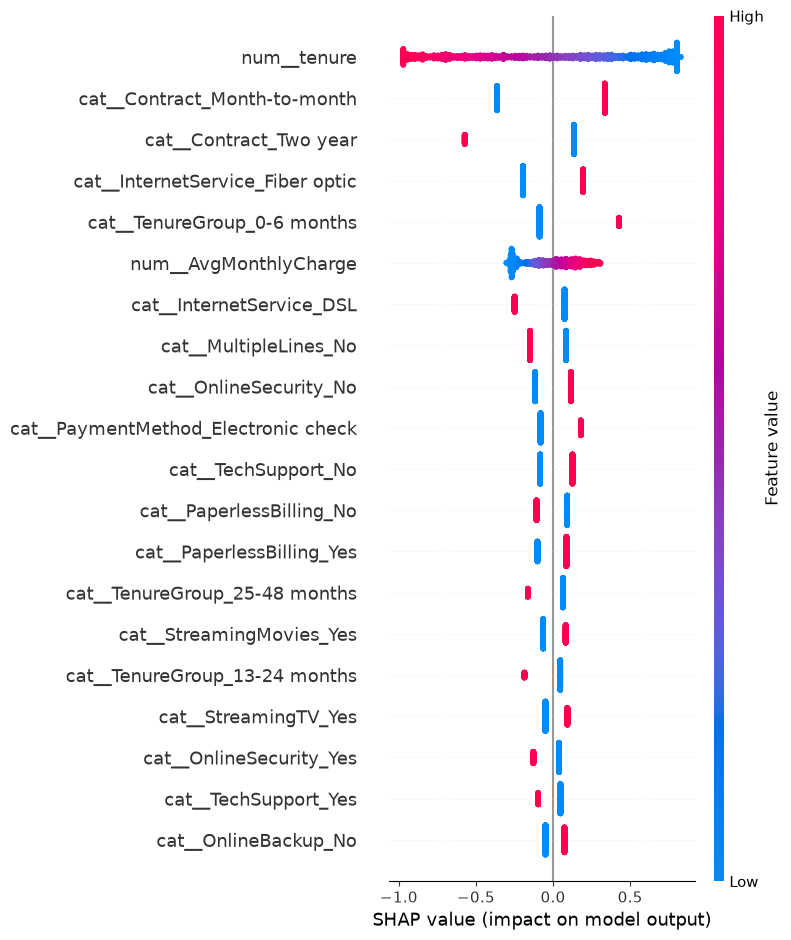

In [ ]:
# SHAP summary plot
shap.summary_plot(
    shap_values_plot,
    X_test_shap[:len(shap_values_plot)],
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig("../outputs/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

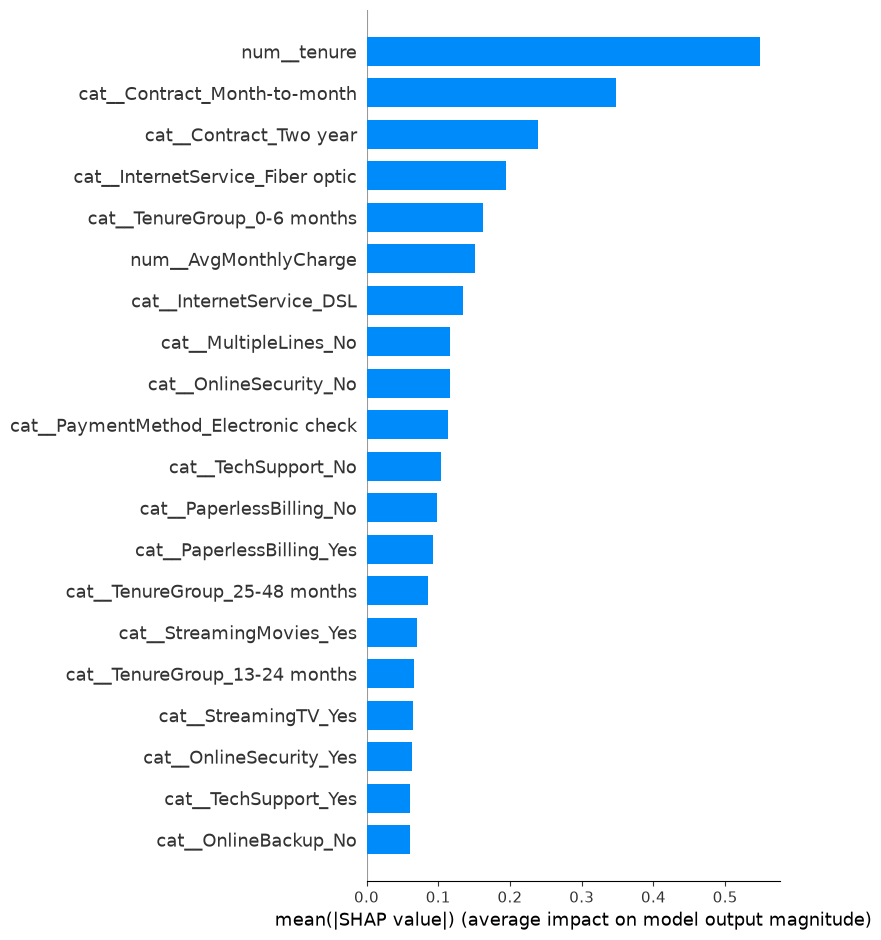

In [ ]:
# SHAP feature-importance bar plot
shap.summary_plot(
    shap_values_plot,
    X_test_shap[:len(shap_values_plot)],
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig("../outputs/shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save final tuned pipeline
final_model_path = "../models/final/best_churn_model.pkl"
joblib.dump(final_model, final_model_path)
print("Saved:", final_model_path)

Saved: ../models/final/best_churn_model.pkl


In [ ]:
# Prove the saved model loads and reproduces predictions
loaded_model = joblib.load(final_model_path)

loaded_predictions = loaded_model.predict(X_test)
loaded_probabilities = loaded_model.predict_proba(X_test)[:, 1]
loaded_auc = roc_auc_score(y_test, loaded_probabilities)

assert np.array_equal(y_test_pred, loaded_predictions)

print("Reload verification: PASSED")
print(f"Reloaded model test AUC: {loaded_auc:.4f}")

Reload verification: PASSED
Reloaded model test AUC: 0.8453


In [ ]:
final_summary = pd.DataFrame([{
    "Selected Model": best_model_name,
    "Tuned CV AUC": search.best_score_,
    "Final Test AUC": final_auc,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1": final_f1,
    "AUC >= 0.80": final_auc >= 0.80
}])

final_summary.to_csv("../outputs/final_model_summary.csv", index=False)
final_summary

,Selected Model,Tuned CV AUC,Final Test AUC,Accuracy,Precision,Recall,F1,AUC >= 0.80
0,Logistic Regression,0.848104,0.8453,0.800568,0.659794,0.513369,0.577444,True


In [ ]:
# Write the model card using the actual measured values
auc_status = "PASS" if final_auc >= 0.80 else "NOT MET"

model_card = f"""# Telecom Customer Churn — Model Card

## Objective
Predict customer churn using the processed telecom customer dataset.

## Models evaluated
- Logistic Regression
- Random Forest
- Gradient Boosting
- Extra Trees
- KNN

## Model selection
The Session 4 winner was selected using the highest mean 5-fold stratified cross-validation ROC-AUC.

Selected model: **{best_model_name}**

Session 4 mean CV AUC: **{cv_df.iloc[0]["CV AUC Mean"]:.4f}**

## Hyperparameter tuning
RandomizedSearchCV was applied to the selected model using 5-fold CV and ROC-AUC scoring.

Tuned CV AUC: **{search.best_score_:.4f}**

## Final held-out test evaluation
The test set was evaluated once after tuning.

| Metric | Score |
|---|---:|
| Accuracy | {final_accuracy:.4f} |
| Precision | {final_precision:.4f} |
| Recall | {final_recall:.4f} |
| F1 | {final_f1:.4f} |
| ROC-AUC | {final_auc:.4f} |

AUC >= 0.80: **{auc_status}**

## Explainability
SHAP explanations were generated and saved to:
- `outputs/shap_summary.png`
- `outputs/shap_feature_importance.png`

## Saved model
`models/final/best_churn_model.pkl`

The saved pipeline was reloaded and its predictions were verified against the original final-model predictions.

## Limitations
The model is an analytical prediction tool, not a guarantee of individual customer behavior. Performance can change on future or materially different customer populations.
"""

with open("../docs/MODEL_CARD.md", "w", encoding="utf-8") as f:
    f.write(model_card)

print("MODEL_CARD.md created.")

MODEL_CARD.md created.


In [ ]:
auc_status = "PASS" if final_auc >= 0.80 else "NOT MET"

choice_doc = f"""# Model Choice Justification

## Selection basis
Five models were evaluated using 5-fold stratified cross-validation. Mean ROC-AUC was the primary selection metric.

Selected model: **{best_model_name}**

Mean CV AUC: **{cv_df.iloc[0]["CV AUC Mean"]:.4f}**

## Hyperparameter tuning
RandomizedSearchCV was used with ROC-AUC scoring.

Tuned CV AUC: **{search.best_score_:.4f}**

## Final test evaluation
The held-out test set was evaluated once after selection and tuning.

- Accuracy: **{final_accuracy:.4f}**
- Precision: **{final_precision:.4f}**
- Recall: **{final_recall:.4f}**
- F1: **{final_f1:.4f}**
- ROC-AUC: **{final_auc:.4f}**

## AUC threshold
Requested threshold: AUC >= 0.80

Observed final test AUC: **{final_auc:.4f}**

Result: **{auc_status}**

The threshold result is reported from the actual test evaluation; no score is altered or fabricated to meet the threshold.
"""

with open("../docs/MODEL_CHOICE.md", "w", encoding="utf-8") as f:
    f.write(choice_doc)

print("MODEL_CHOICE.md created.")

MODEL_CHOICE.md created.


In [ ]:
required_files = [
    "../outputs/roc_curves.png",
    "../outputs/confusion_matrix_top2.png",
    "../outputs/final_roc_curve.png",
    "../outputs/shap_summary.png",
    "../models/final/best_churn_model.pkl",
    "../docs/MODEL_CARD.md",
    "../docs/MODEL_CHOICE.md"
]

print("=" * 70)
print("FINAL VALIDATION")
print("=" * 70)
print(f"Best model tuned : {best_model_name}")
print(f"Tuned CV AUC     : {search.best_score_:.4f}")
print(f"Final Test AUC   : {final_auc:.4f}")
print(f"AUC >= 0.80      : {'PASS' if final_auc >= 0.80 else 'NOT MET'}")
print(f"Reloaded AUC     : {loaded_auc:.4f}")
print()

for path in required_files:
    print(f"{'FOUND' if os.path.exists(path) else 'MISSING'}: {path}")

FINAL VALIDATION
Best model tuned : Logistic Regression
Tuned CV AUC     : 0.8481
Final Test AUC   : 0.8453
AUC >= 0.80      : PASS
Reloaded AUC     : 0.8453

FOUND: ../outputs/roc_curves.png
FOUND: ../outputs/confusion_matrix_top2.png
FOUND: ../outputs/final_roc_curve.png
FOUND: ../outputs/shap_summary.png
FOUND: ../models/final/best_churn_model.pkl
FOUND: ../docs/MODEL_CARD.md
FOUND: ../docs/MODEL_CHOICE.md
